# Bank Distress Early-Warning Model — EDA
**MSDS 696 Data Science Practicum II · Oussama Ennaciri**

Works off `panel_clean.parquet` — built in `feature_selection.ipynb`
(1990Q1+, regime-switched PCA tier, `onset_4q` target), then reviewed and flagged
in `cleaning.ipynb` (`near_merge_exit`, `roa_artifact`, `fast_failure`).
Cleaning added flags only: no values or labels were changed, so every chart below
is unaffected. Known data issues: `data_concerns.md`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

panel = pd.read_parquet(Path("..") / "data" / "processed" / "panel_clean.parquet")
print(f"panel: {panel.shape[0]:,} rows x {panel.shape[1]} cols "
      f"({panel['REPDTE'].min():%Y-%m} to {panel['REPDTE'].max():%Y-%m})")

panel: 1,258,888 rows x 66 cols (1990-03 to 2026-03)


## Chart style

Navy/gold house palette, high-resolution output.

In [2]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

NAVY, GOLD, MIDGRAY, HAIRLINE = "#1F3864", "#F2C14E", "#595959", "#C8C8C8"
NAVY_GOLD = LinearSegmentedColormap.from_list("navy_gold", [GOLD, "#FFFFFF", NAVY])
NAVY_SEQ = LinearSegmentedColormap.from_list("navy_seq", ["#FFFFFF", NAVY])

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": MIDGRAY,
    "axes.edgecolor": HAIRLINE, "axes.labelcolor": MIDGRAY,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": HAIRLINE, "grid.linewidth": 0.6,
    "xtick.color": MIDGRAY, "ytick.color": MIDGRAY,
    "axes.prop_cycle": mpl.cycler(color=[NAVY, GOLD, MIDGRAY]),
    "legend.frameon": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
panel = panel.sort_values(["CERT", "REPDTE"]).reset_index(drop=True)
healthy = panel[panel["is_healthy"] == True]

# plain-language names for FDIC field codes, so no chart ever shows a raw code
FEATURE_NAMES = {
    "RBCRWAJ": "Total RBC ratio", "RBC1RWAJ": "Tier 1 RBC ratio", "RBC1AAJ": "Leverage ratio",
    "RBCT1CER": "CET1 ratio", "EQV": "Equity / assets", "NPERFV": "Nonperforming assets / assets",
    "NCLNLSR": "Noncurrent loans / gross loans", "NTLNLSR": "Net charge-offs / loans",
    "LNATRESR": "Loan loss reserve / gross loans", "P3ASSETR": "30\u201389 days past due / assets",
    "P9ASSETR": "90+ days past due / assets", "ORER": "Other real estate owned / assets",
    "ELNATRR": "Loan loss provisions / assets", "LNRECONSR": "Construction & land loans / assets",
    "LNRENRESR": "Commercial real estate loans / assets", "LNREMULTR": "Multifamily loans / assets",
    "LNRERESR": "1\u20134 family residential loans / assets", "IDNCCIR": "Commercial & industrial loans / assets",
    "LNCONR": "Consumer loans / assets", "BROR": "Brokered deposits / deposits",
    "LNLSDEPR": "Loans & leases / deposits", "CHBALR": "Cash & due from banks / assets",
    "ROA": "Return on assets", "ROE": "Return on equity", "NIMY": "Net interest margin",
    "EEFFR": "Efficiency ratio", "AGE_YEARS": "Bank age (years)",
    "SCHA": "HTM securities, amortized cost", "SCHF": "HTM securities, fair value",
}
print("style set")

style set


## 0 · How much of the system was ever in trouble

Of *all* banks each year (healthy and already-distressed together), what share were
currently in the danger zone. Context for the target below — this counts everyone
sick at a point in time, not just new cases starting.

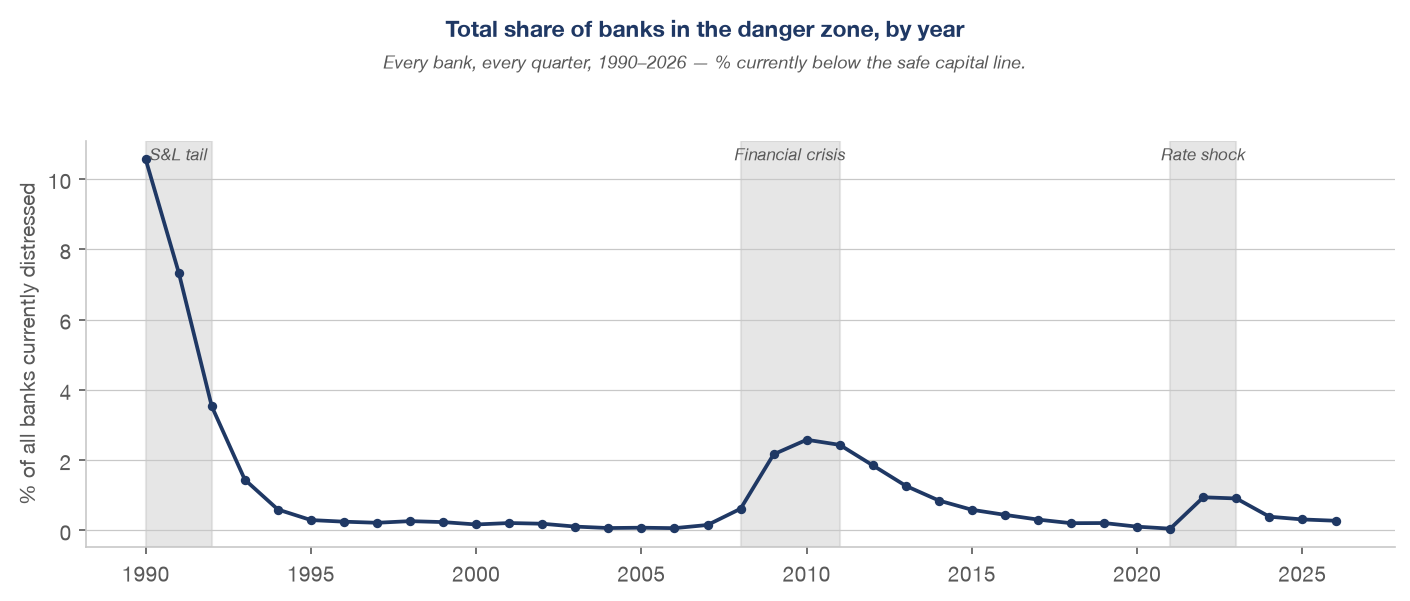

In [3]:
prevalence = panel.assign(year=panel["REPDTE"].dt.year).groupby("year")["is_distressed"].mean() * 100

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(prevalence.index, prevalence.values, marker="o", markersize=3.5, color=NAVY, linewidth=1.8)
for span, label in [((1990, 1992), "S&L tail"), ((2008, 2011), "Financial crisis"), ((2021, 2023), "Rate shock")]:
    ax.axvspan(span[0], span[1], color=HAIRLINE, alpha=0.45)
    ax.text(sum(span)/2, ax.get_ylim()[1]*0.95, label, ha="center", fontsize=8, color=MIDGRAY, style="italic")
plt.suptitle("Total share of banks in the danger zone, by year", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Every bank, every quarter, 1990\u20132026 \u2014 % currently below the safe capital line.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_ylabel("% of all banks currently distressed")
plt.tight_layout(); plt.show()

## 1 · Trouble over time

Share of healthy banks that fall into the danger zone within the next year, by year.

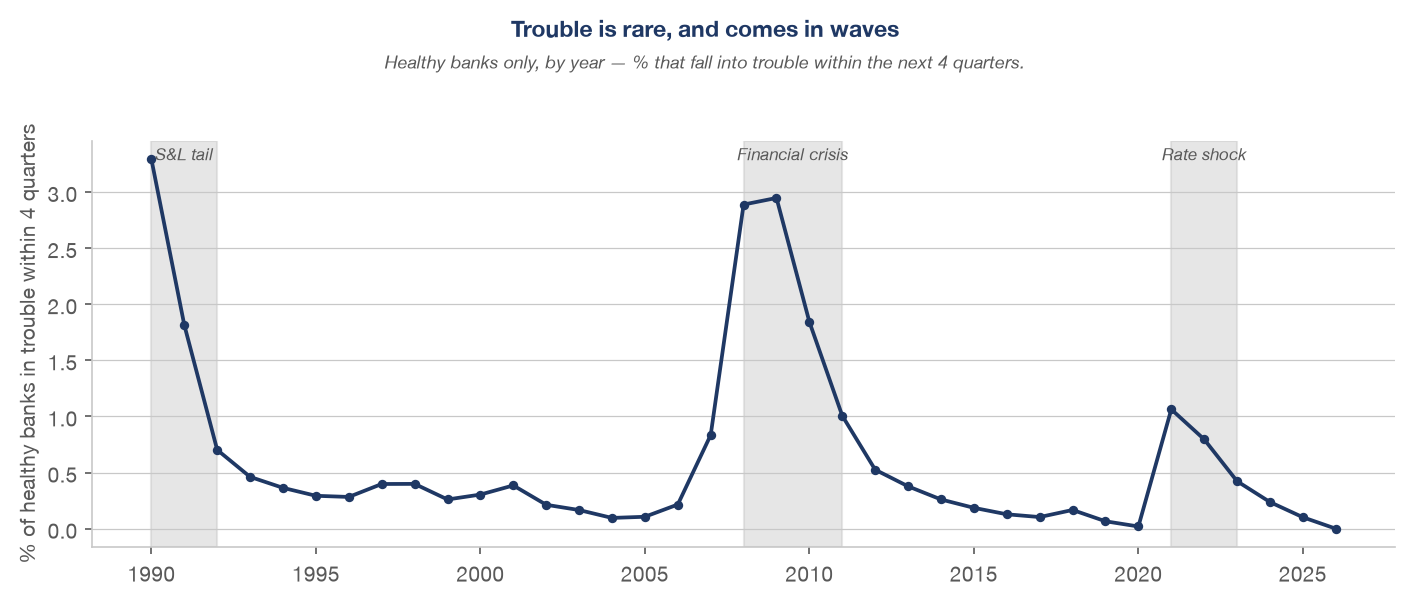

In [4]:
rate_by_year = healthy.assign(year=healthy["REPDTE"].dt.year).groupby("year")["onset_4q"].mean() * 100

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(rate_by_year.index, rate_by_year.values, marker="o", markersize=3.5, color=NAVY, linewidth=1.8)
for span, label in [((1990, 1992), "S&L tail"), ((2008, 2011), "Financial crisis"), ((2021, 2023), "Rate shock")]:
    ax.axvspan(span[0], span[1], color=HAIRLINE, alpha=0.45)
    ax.text(sum(span)/2, ax.get_ylim()[1]*0.95, label, ha="center", fontsize=8, color=MIDGRAY, style="italic")
plt.suptitle("Trouble is rare, and comes in waves", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Healthy banks only, by year \u2014 % that fall into trouble within the next 4 quarters.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_ylabel("% of healthy banks in trouble within 4 quarters")
plt.tight_layout(); plt.show()

## 2 · Repeat offenders

How many distress episodes does a bank have across its whole life? An episode starts when a bank crosses from healthy into the danger zone.

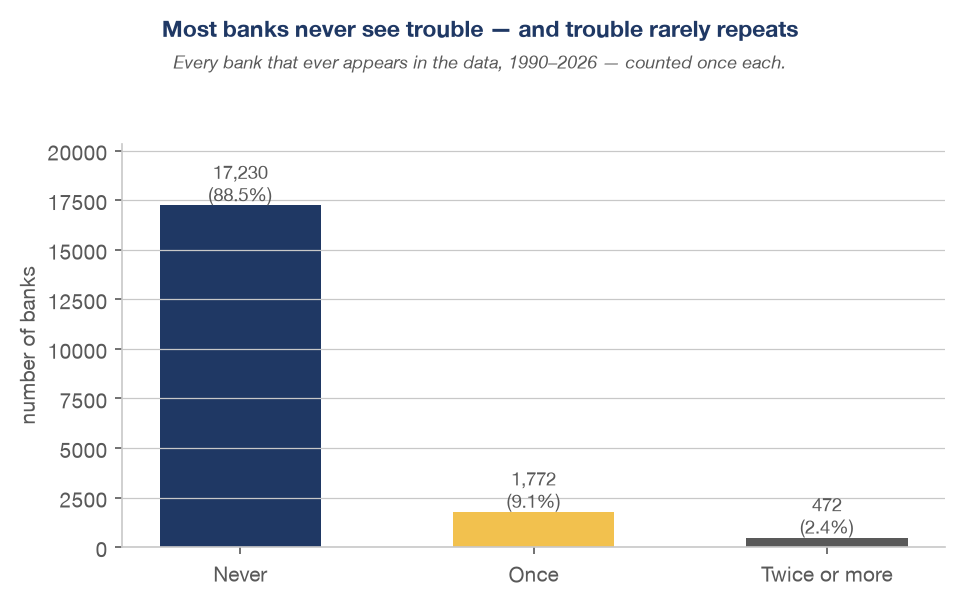

In [5]:
prev_healthy = panel.groupby("CERT")["is_healthy"].shift(1)
episode_start = (panel["is_distressed"] == True) & (prev_healthy == True)
episodes_per_bank = episode_start.groupby(panel["CERT"]).sum()

dist = pd.Series({
    "Never": (episodes_per_bank == 0).sum(),
    "Once": (episodes_per_bank == 1).sum(),
    "Twice or more": (episodes_per_bank >= 2).sum(),
})
fig, ax = plt.subplots(figsize=(6.5, 3.6))
bars = ax.bar(dist.index, dist.values, color=[NAVY, GOLD, MIDGRAY], width=0.55)
for b, v in zip(bars, dist.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(episodes_per_bank):.1%})",
            ha="center", va="bottom", fontsize=9, color=MIDGRAY)
plt.suptitle("Most banks never see trouble — and trouble rarely repeats", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Every bank that ever appears in the data, 1990\u20132026 \u2014 counted once each.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_ylabel("number of banks")
ax.set_ylim(0, dist.max()*1.18)
plt.tight_layout(); plt.show()

## 4 · Sick vs. healthy compared

The four classic CAMELS-style vitals, healthy banks vs. banks currently in the danger zone.

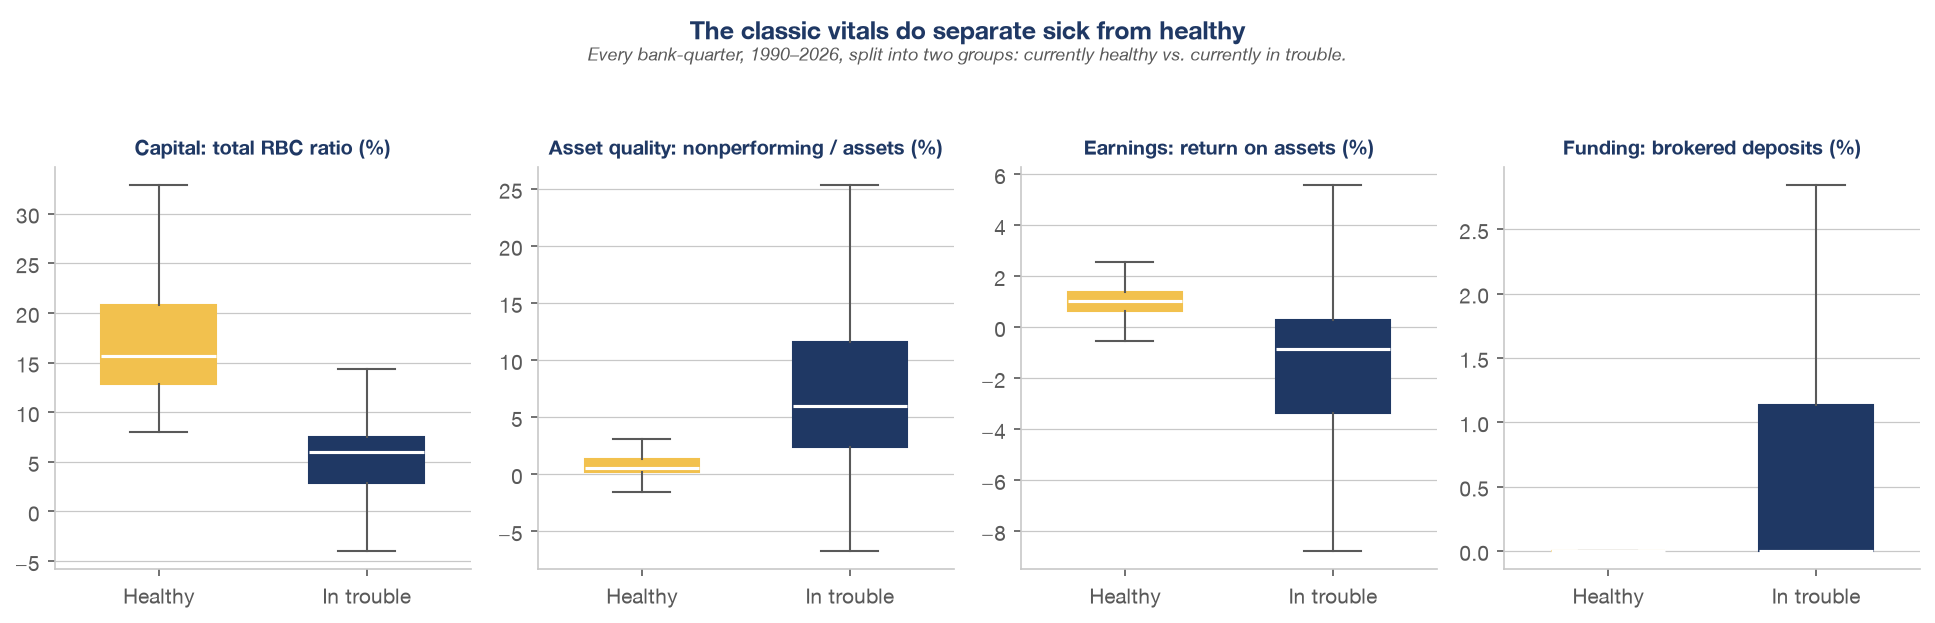

In [6]:
vitals = [
    ("RBCRWAJ", "Capital: total RBC ratio (%)"),
    ("NPERFV", "Asset quality: nonperforming / assets (%)"),
    ("ROA", "Earnings: return on assets (%)"),
    ("BROR", "Funding: brokered deposits (%)"),
]
p_clean = panel.copy()
p_clean.loc[(p_clean["RBCRWAJ"] == 0) & p_clean["RBC1RWAJ"].isna(), "RBCRWAJ"] = np.nan
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
for ax, (col, title) in zip(axes, vitals):
    data = [p_clean.loc[p_clean["is_healthy"] == True, col].dropna(),
            p_clean.loc[p_clean["is_distressed"] == True, col].dropna()]
    box = ax.boxplot(data, showfliers=False, patch_artist=True, widths=0.55,
                     medianprops={"color": "white", "linewidth": 1.5})
    for patch, color in zip(box["boxes"], [GOLD, NAVY]):
        patch.set_facecolor(color); patch.set_edgecolor(color)
    for el in ["whiskers", "caps"]:
        for line in box[el]: line.set_color(MIDGRAY)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Healthy", "In trouble"])
    ax.set_title(title, fontsize=9.5)
plt.suptitle("The classic vitals do separate sick from healthy", color=NAVY, fontweight="bold", y=1.08)
fig.text(0.5, 1.00, "Every bank-quarter, 1990\u20132026, split into two groups: currently healthy vs. currently in trouble.",
         ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
plt.tight_layout(); plt.show()

## 5 · The road to trouble

Median path of the vitals over the 8 quarters before a bank's first crossing into the danger zone.

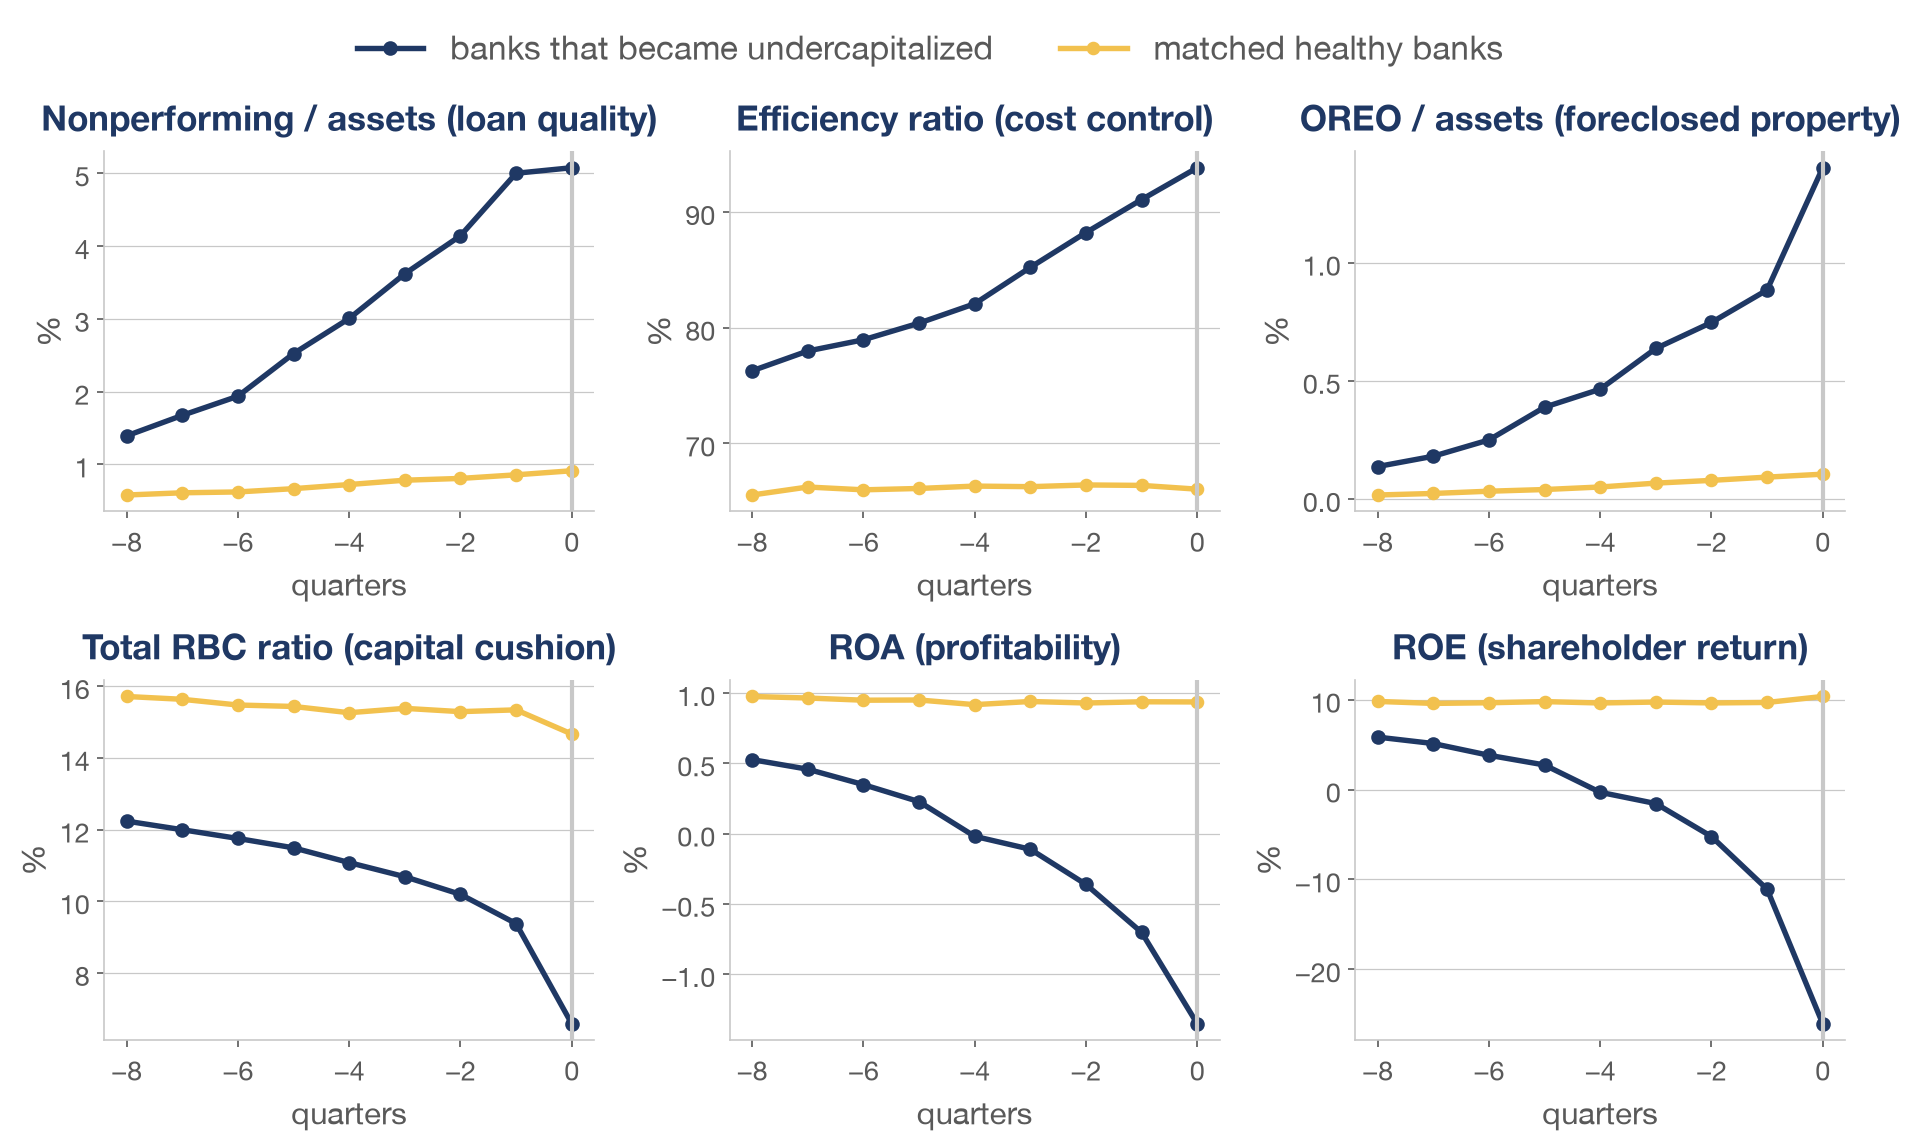

In [7]:
panel["_pos"] = panel.groupby("CERT").cumcount()
first_dis = panel[panel["is_distressed"] == True].groupby("CERT")["_pos"].min().rename("event_pos")
tr = panel.merge(first_dis, on="CERT", how="inner")
tr["rel_q"] = tr["_pos"] - tr["event_pos"]
window = tr[(tr["rel_q"] >= -8) & (tr["rel_q"] <= 0)]

# --- matched control group: never-crossed banks, pseudo-anchored to the same calendar quarters ---
crossed_certs = set(first_dis.index)
event_dates = tr.loc[tr["rel_q"] == 0, "REPDTE"]
ctrl_pool = panel[~panel["CERT"].isin(crossed_certs) & (panel["is_healthy"] == True)]

rng = np.random.default_rng(42)
anchor_rows = []
for qtr, n in event_dates.value_counts().items():
    cand = ctrl_pool[ctrl_pool["REPDTE"] == qtr]
    if len(cand) == 0:
        continue
    take = min(n, len(cand))
    anchor_rows.append(cand.sample(n=take, random_state=rng.integers(1e9)))
anchors = pd.concat(anchor_rows)[["CERT", "_pos"]].rename(columns={"_pos": "event_pos"})

ctrl = panel.merge(anchors, on="CERT", how="inner")
ctrl["rel_q"] = ctrl["_pos"] - ctrl["event_pos"]
ctrl_window = ctrl[(ctrl["rel_q"] >= -8) & (ctrl["rel_q"] <= 0)]

cols = ["NPERFV", "EEFFR", "ORER", "RBCRWAJ", "ROA", "ROE"]
titles = ["Nonperforming / assets (loan quality)", "Efficiency ratio (cost control)", "OREO / assets (foreclosed property)",
          "Total RBC ratio (capital cushion)", "ROA (profitability)", "ROE (shareholder return)"]
paths = window.groupby("rel_q")[cols].median()
ctrl_paths = ctrl_window.groupby("rel_q")[cols].median()

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.2))
for ax, col, title in zip(axes.flat, cols, titles):
    ax.plot(paths.index, paths[col], marker="o", markersize=6, color=NAVY, linewidth=2.6, label="banks that became undercapitalized")
    ax.plot(ctrl_paths.index, ctrl_paths[col], marker="o", markersize=5.5, color=GOLD, linewidth=2.6, label="matched healthy banks")
    ax.axvline(0, color=HAIRLINE, linewidth=2)
    ax.set_title(title, fontsize=17, pad=10)
    ax.set_xticks([-8, -6, -4, -2, 0])
    ax.tick_params(labelsize=13)
    ax.set_ylabel("%", fontsize=15)
    ax.set_xlabel("quarters", fontsize=15)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.07), fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("../Week 3/assets/road_to_trouble.png", dpi=220, bbox_inches="tight")
plt.show()

## 5b · Same story, but for 10 real banks (personal view, not for the report)

Chart 5 shows the *median* — the typical path. This shows 10 individual banks, chosen at
random from banks with at least 5 quarters of history before their first crossing, so the
actual variety underneath that median is visible. Same alignment: 0 = each bank's own
first crossing into trouble. Only first crossings are shown here too, for consistency with
chart 5 — a bank that crossed twice only appears once.

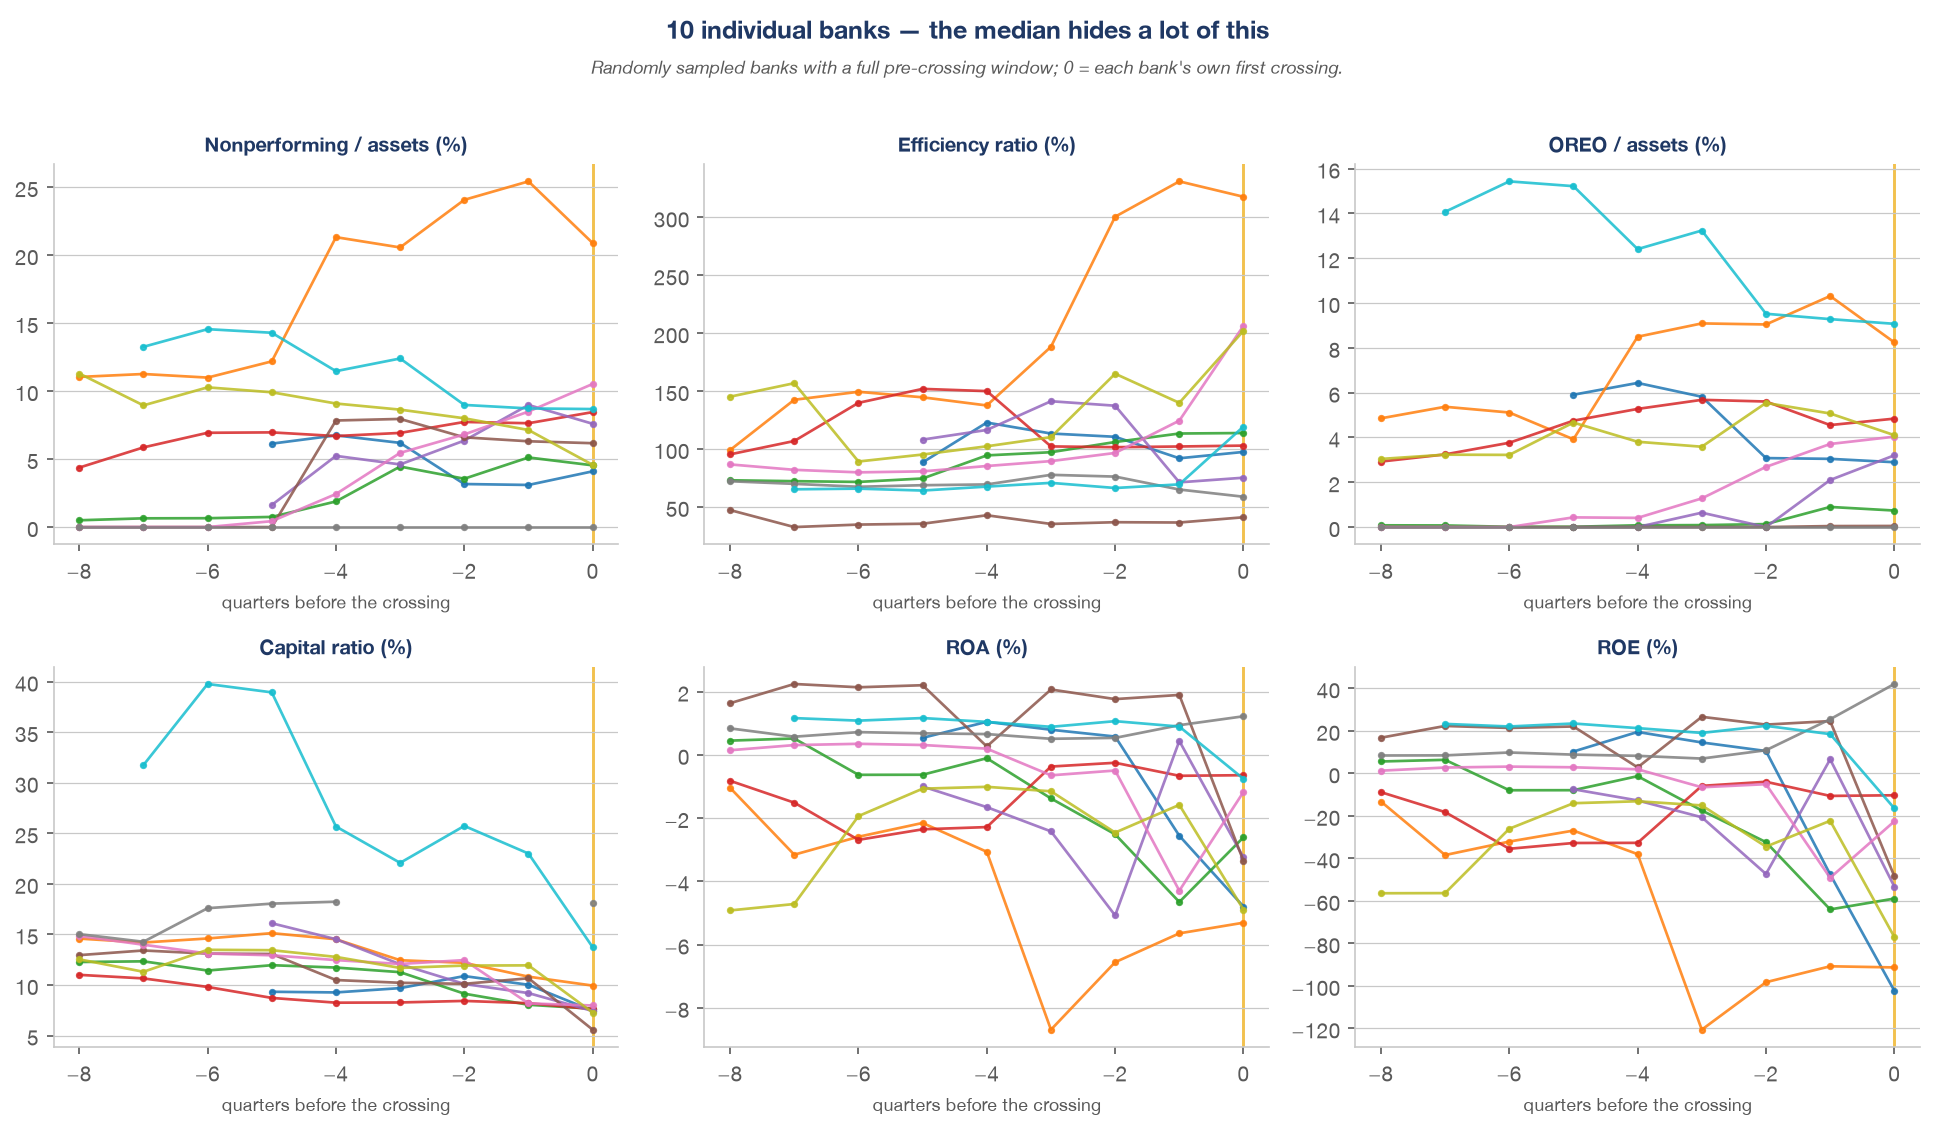

sample CERTs: [np.int64(29849), np.int64(57431), np.int64(34561), np.int64(35259), np.int64(27456), np.int64(18265), np.int64(57928), np.int64(3336), np.int64(15083), np.int64(32643)]


In [8]:
window_full = tr[(tr["rel_q"] >= -8) & (tr["rel_q"] <= 0)]
long_enough = window_full.groupby("CERT").size()
eligible = long_enough[long_enough >= 5].index

rng = np.random.default_rng(7)
sample_certs = rng.choice(eligible, size=10, replace=False)

sample = window_full[window_full["CERT"].isin(sample_certs)]
colors = plt.cm.tab10(np.linspace(0, 1, 10))
cert_color = dict(zip(sample_certs, colors))

cols = ["NPERFV", "EEFFR", "ORER", "RBCRWAJ", "ROA", "ROE"]
titles = ["Nonperforming / assets (%)", "Efficiency ratio (%)", "OREO / assets (%)",
          "Capital ratio (%)", "ROA (%)", "ROE (%)"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
for ax, col, title in zip(axes.flat, cols, titles):
    for cert in sample_certs:
        b = sample[sample["CERT"] == cert].sort_values("rel_q")
        ax.plot(b["rel_q"], b[col], color=cert_color[cert], linewidth=1.3, alpha=0.85, marker="o", markersize=2.5)
    ax.axvline(0, color=GOLD, linewidth=1.4, zorder=0)
    ax.set_title(title, fontsize=9.5)
    ax.set_xticks([-8, -6, -4, -2, 0])
    ax.set_xlabel("quarters before the crossing", fontsize=8.5)
plt.suptitle("10 individual banks — the median hides a lot of this", color=NAVY, fontweight="bold", fontsize=12, y=1.04)
fig.text(0.5, 0.985, "Randomly sampled banks with a full pre-crossing window; 0 = each bank's own first crossing.",
         ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
plt.tight_layout(); plt.show()

print("sample CERTs:", list(sample_certs))

## 6 · Rank the features

Each feature scored alone on how well it tells \"in trouble within a year\" from \"stays fine\" (AUC, 0.5 = coin flip). Computed on healthy rows only.

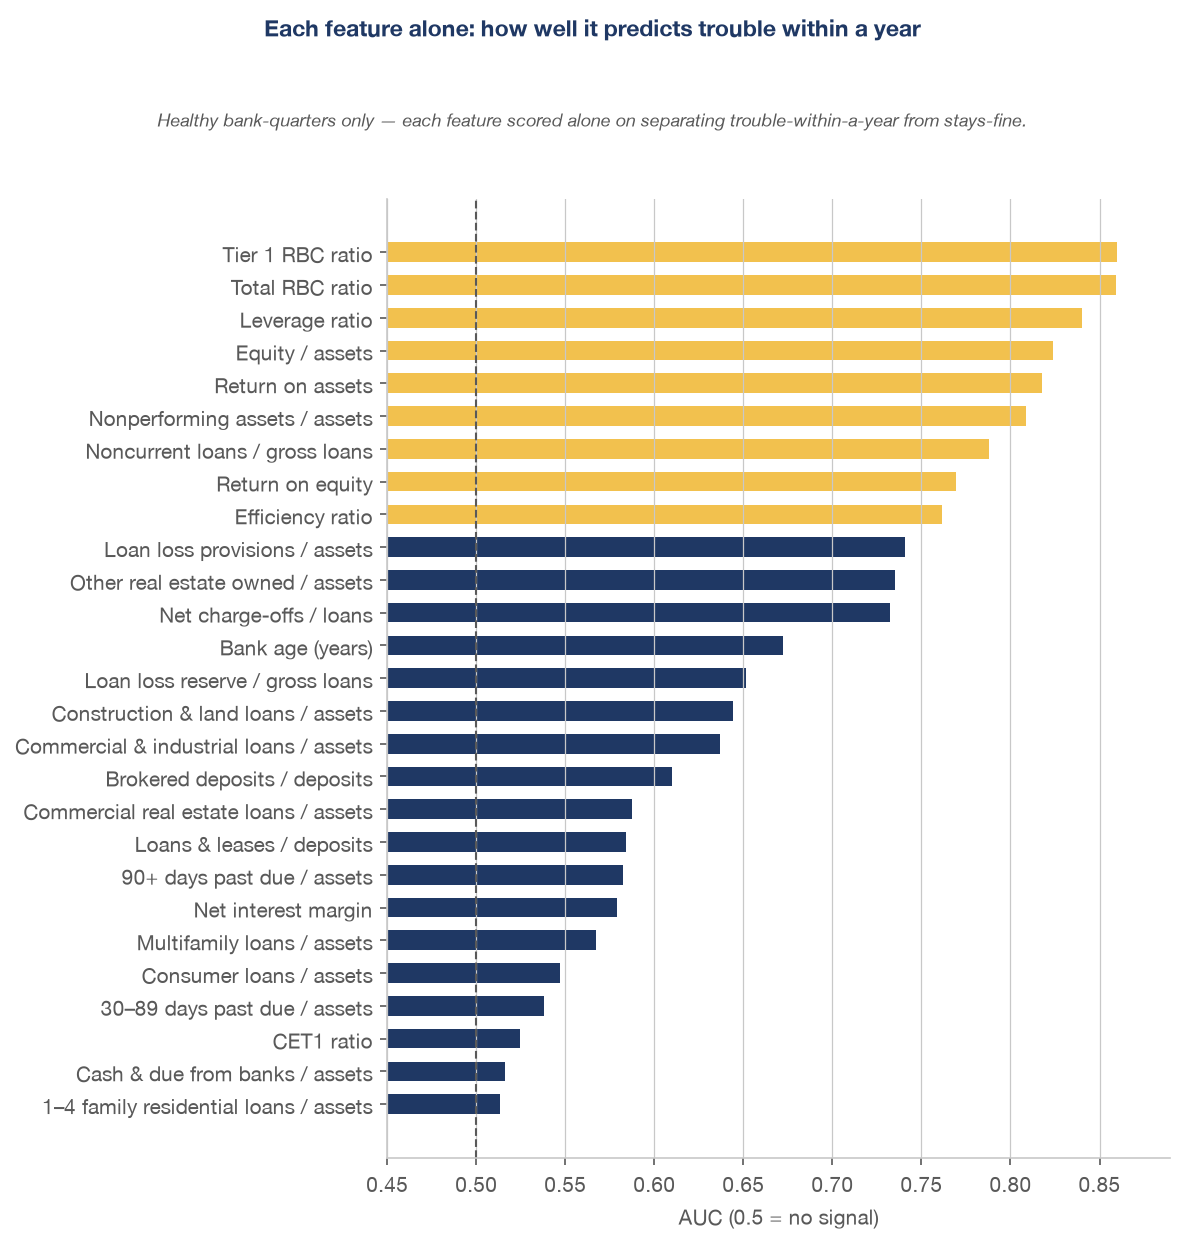

Tier 1 RBC ratio                  0.860
Total RBC ratio                   0.859
Leverage ratio                    0.840
Equity / assets                   0.824
Return on assets                  0.818
Nonperforming assets / assets     0.809
Noncurrent loans / gross loans    0.788
Return on equity                  0.769
dtype: float64


In [9]:
from scipy.stats import rankdata

def auc_1d(x, y):
    m = x.notna() & y.notna()
    x, y = x[m].to_numpy(), y[m].to_numpy().astype(bool)
    if y.sum() < 50 or (~y).sum() < 50: return np.nan
    r = rankdata(x)
    auc = (r[y].mean() - (y.sum() + 1) / 2) / (~y).sum()
    return max(auc, 1 - auc)

feature_cols = ["RBCRWAJ", "RBC1RWAJ", "RBC1AAJ", "RBCT1CER", "EQV", "NPERFV", "NCLNLSR",
                "NTLNLSR", "LNATRESR", "P3ASSETR", "P9ASSETR", "ORER", "ELNATRR",
                "LNRECONSR", "LNRENRESR", "LNREMULTR", "LNRERESR", "IDNCCIR", "LNCONR",
                "BROR", "LNLSDEPR", "CHBALR", "ROA", "ROE", "NIMY", "EEFFR", "AGE_YEARS"]
h_clean = healthy.copy()
h_clean.loc[(h_clean["RBCRWAJ"] == 0) & h_clean["RBC1RWAJ"].isna(), "RBCRWAJ"] = np.nan
y = h_clean["onset_4q"]
aucs = pd.Series({c: auc_1d(h_clean[c], y) for c in feature_cols}).dropna().sort_values()
aucs.index = [FEATURE_NAMES.get(c, c) for c in aucs.index]

fig, ax = plt.subplots(figsize=(8, 7.5))
colors = [GOLD if v >= 0.75 else NAVY for v in aucs.values]
ax.barh(aucs.index, aucs.values, color=colors, height=0.6)
ax.axvline(0.5, color=MIDGRAY, linewidth=1, linestyle="--")
ax.set_xlim(0.45, max(0.85, aucs.max() + 0.03))
plt.suptitle("Each feature alone: how well it predicts trouble within a year", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Healthy bank-quarters only \u2014 each feature scored alone on separating trouble-within-a-year from stays-fine.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_xlabel("AUC (0.5 = no signal)")
ax.grid(axis="x"); ax.grid(axis="y", linewidth=0)
plt.tight_layout(); plt.show()
print(aucs.sort_values(ascending=False).head(8).round(3))

## 7 · The SVB story

Silicon Valley Bank vs. First-Citizens (similar size, opposite outcomes): the loss hiding in the held-to-maturity bond book, invisible to the capital ratio.

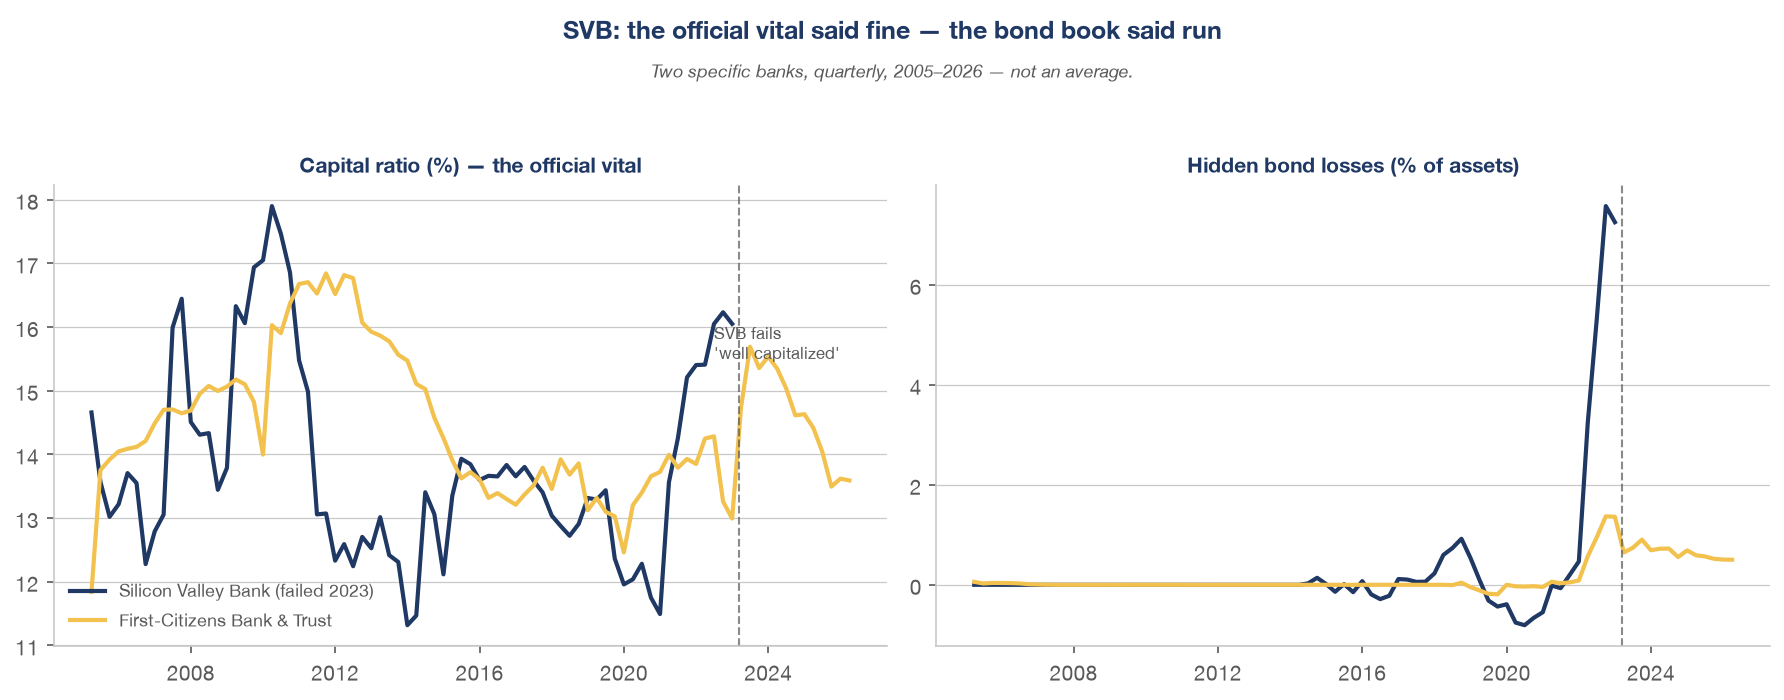

In [10]:
CASE = {24735: "Silicon Valley Bank (failed 2023)", 11063: "First-Citizens Bank & Trust"}
cs = panel[(panel["CERT"].isin(CASE)) & (panel["REPDTE"] >= "2005-01-01")].copy()
cs["htm_loss"] = (cs["SCHA"] - cs["SCHF"]) / cs["ASSET"] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, title in zip(axes, ["RBCRWAJ", "htm_loss"],
                          ["Capital ratio (%) — the official vital", "Hidden bond losses (% of assets)"]):
    for cert, name in CASE.items():
        sub = cs[cs["CERT"] == cert]
        ax.plot(sub["REPDTE"], sub[col], label=name, linewidth=2.0)
    ax.axvline(pd.Timestamp("2023-03-10"), color=MIDGRAY, linestyle="--", alpha=0.7, linewidth=1)
    ax.set_title(title, fontsize=10)
axes[0].annotate("SVB fails\n'well capitalized'", xy=(pd.Timestamp("2022-06-30"), 15.5), fontsize=8, color=MIDGRAY)
axes[0].legend(fontsize=8.5, loc="lower left")
plt.suptitle("SVB: the official vital said fine — the bond book said run", color=NAVY, fontweight="bold", y=1.10)
fig.text(0.5, 1.00, "Two specific banks, quarterly, 2005\u20132026 \u2014 not an average.",
         ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
plt.tight_layout(); plt.show()

## 7b · SVB alone, all six vitals

Same six metrics as chart 5, but for one real bank's own calendar timeline instead of a median. Silicon Valley Bank, quarterly, 2005 to failure.

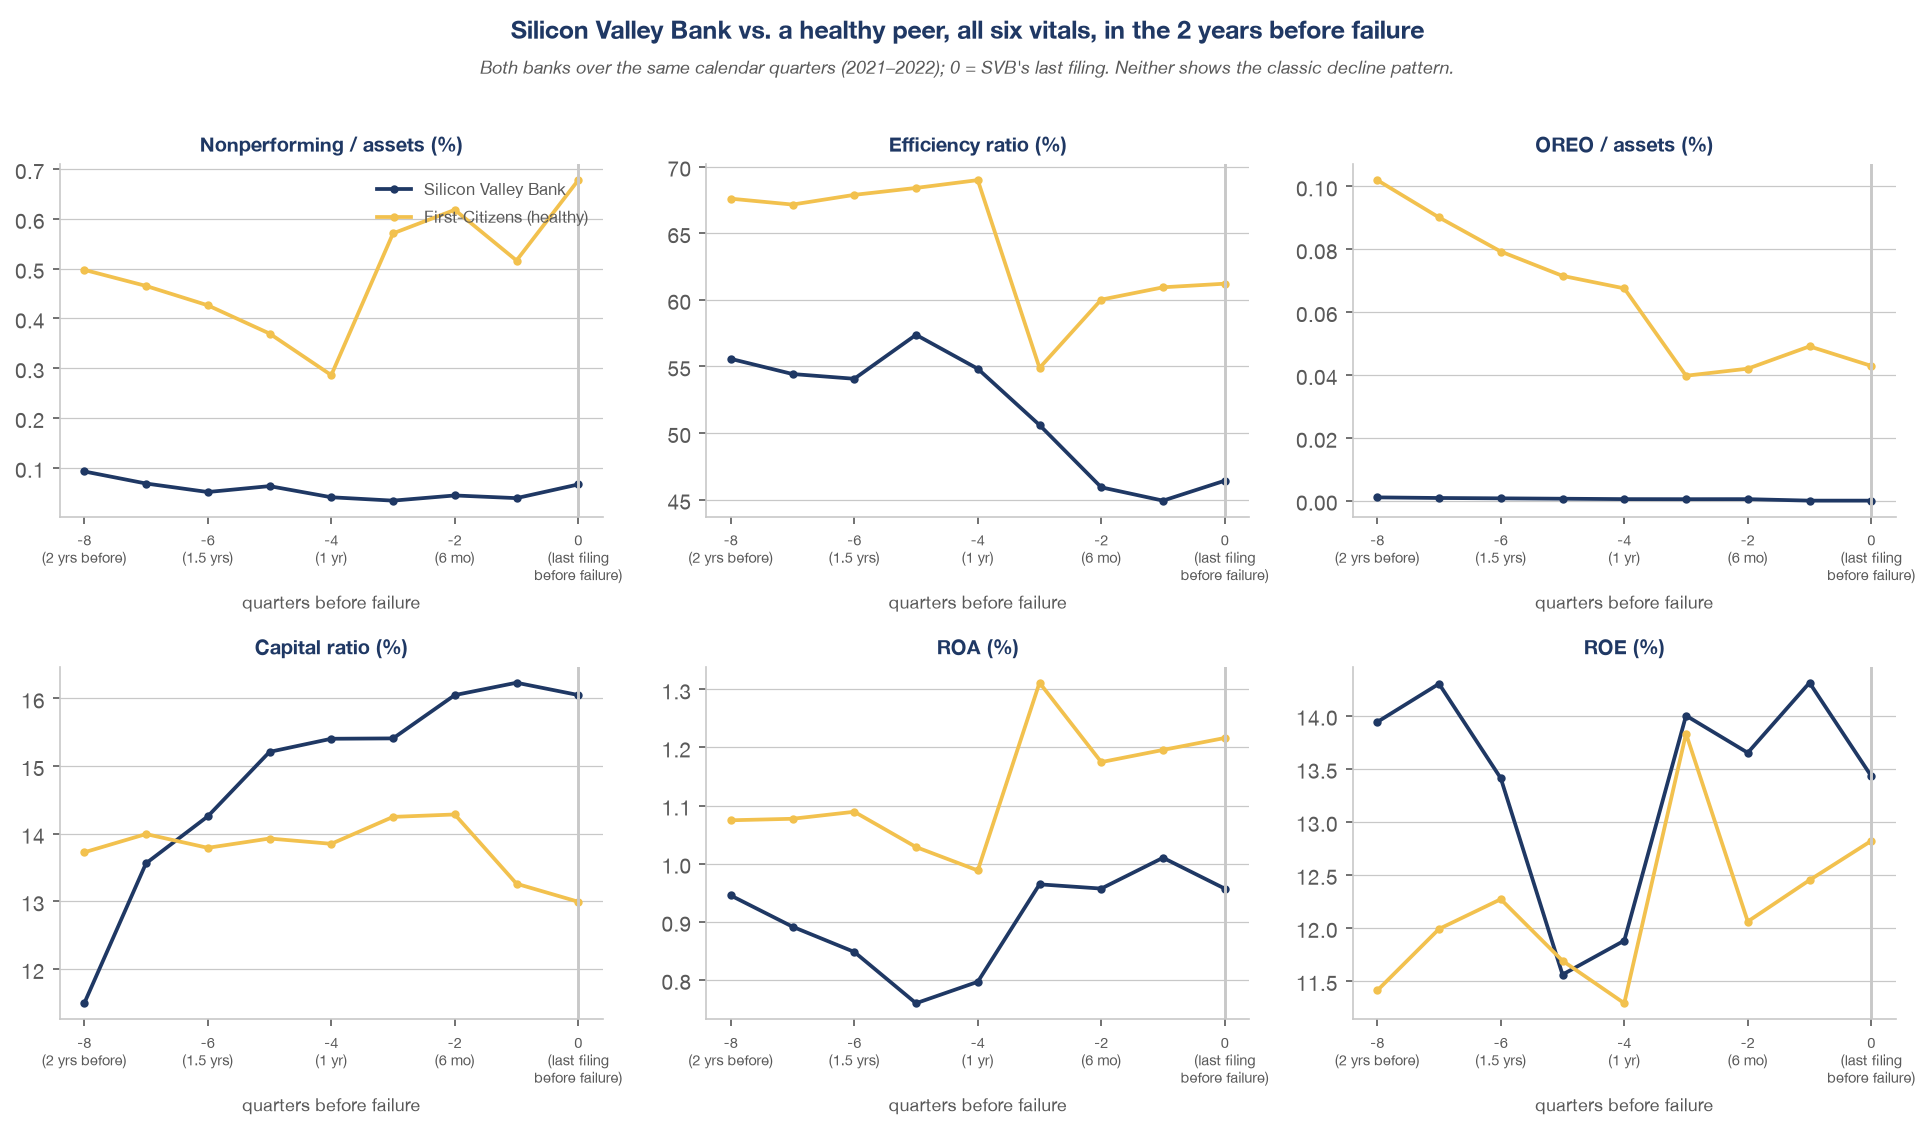

In [11]:
def rel_window(cert, anchor_to_last=True, ref_dates=None):
    b = panel[panel["CERT"] == cert].sort_values("REPDTE").reset_index(drop=True)
    if anchor_to_last:
        b["rel_q"] = b.index - b.index.max()
    else:
        # anchor to the same calendar dates as the reference bank's window
        b = b[b["REPDTE"].isin(ref_dates.values())].copy()
        date_to_rel = {v: k for k, v in ref_dates.items()}
        b["rel_q"] = b["REPDTE"].map(date_to_rel)
    return b[b["rel_q"] >= -8]

svb = rel_window(24735)
svb_dates = dict(zip(svb["rel_q"], svb["REPDTE"]))
fcb = rel_window(11063, anchor_to_last=False, ref_dates=svb_dates)

cols = ["NPERFV", "EEFFR", "ORER", "RBCRWAJ", "ROA", "ROE"]
titles = ["Nonperforming / assets (%)", "Efficiency ratio (%)", "OREO / assets (%)",
          "Capital ratio (%)", "ROA (%)", "ROE (%)"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
for ax, col, title in zip(axes.flat, cols, titles):
    ax.plot(svb["rel_q"], svb[col], color=NAVY, linewidth=1.8, marker="o", markersize=3, label="Silicon Valley Bank")
    ax.plot(fcb["rel_q"], fcb[col], color=GOLD, linewidth=1.8, marker="o", markersize=3, label="First-Citizens (healthy)")
    ax.axvline(0, color=HAIRLINE, linewidth=1.4)
    ax.set_title(title, fontsize=9.5)
    ax.set_xticks([-8, -6, -4, -2, 0])
    ax.set_xticklabels(["-8\n(2 yrs before)", "-6\n(1.5 yrs)", "-4\n(1 yr)", "-2\n(6 mo)", "0\n(last filing\nbefore failure)"], fontsize=7)
    ax.set_xlabel("quarters before failure", fontsize=8.5)
axes.flat[0].legend(fontsize=8, loc="upper right")
plt.suptitle("Silicon Valley Bank vs. a healthy peer, all six vitals, in the 2 years before failure", color=NAVY, fontweight="bold", fontsize=12, y=1.04)
fig.text(0.5, 0.985, "Both banks over the same calendar quarters (2021\u20132022); 0 = SVB's last filing. Neither shows the classic decline pattern.",
         ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
plt.tight_layout(); plt.show()

## 7c · The metrics that actually did flag it — tested against the healthy peer

Adding First-Citizens as a control changed the conclusion: of the four candidate warning
metrics, only one is truly SVB-specific. **HTM unrealized losses** blew out to 7.5% of assets
for SVB vs 1.4% for the peer — the real signal. AFS losses rose for *both* banks (the 2022
rate shock hit every bond portfolio — system-wide, not bank-specific). The cash decline was
similar for both. And First-Citizens' asset-growth spike is the CIT Group merger (Jan 2022),
an M&A artifact, not organic growth — same accounting-noise issue as concern #6.

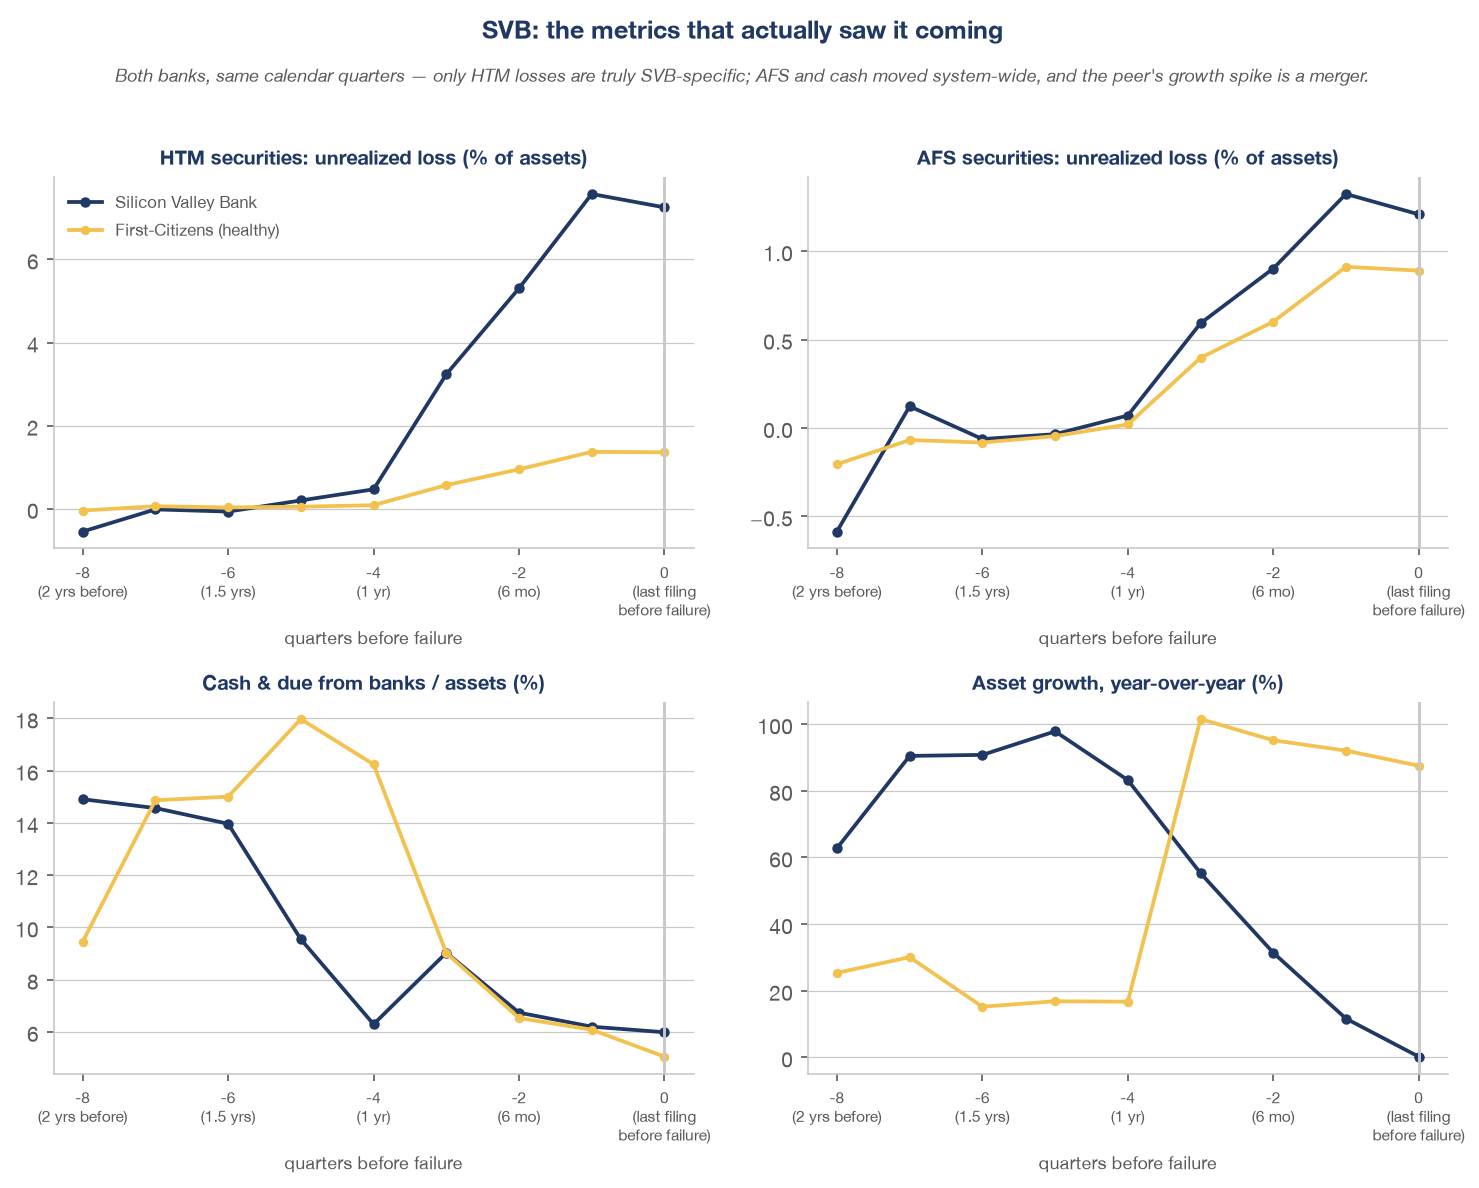

In [12]:
def prep_flags(cert, ref_dates=None):
    b = panel[panel["CERT"] == cert].sort_values("REPDTE").reset_index(drop=True)
    b["htm_loss"] = (b["SCHA"] - b["SCHF"]) / b["ASSET"] * 100
    b["afs_loss"] = (b["SCAA"] - b["SCAF"]) / b["ASSET"] * 100
    b["asset_growth_yoy"] = b["ASSET"].pct_change(4) * 100
    if ref_dates is None:
        b["rel_q"] = b.index - b.index.max()
    else:
        b = b[b["REPDTE"].isin(ref_dates.values())].copy()
        date_to_rel = {v: k for k, v in ref_dates.items()}
        b["rel_q"] = b["REPDTE"].map(date_to_rel)
    return b[b["rel_q"] >= -8]

svb = prep_flags(24735)
svb_dates = dict(zip(svb["rel_q"], svb["REPDTE"]))
fcb = prep_flags(11063, ref_dates=svb_dates)

cols = ["htm_loss", "afs_loss", "CHBALR", "asset_growth_yoy"]
titles = ["HTM securities: unrealized loss (% of assets)", "AFS securities: unrealized loss (% of assets)",
          "Cash & due from banks / assets (%)", "Asset growth, year-over-year (%)"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, col, title in zip(axes.flat, cols, titles):
    ax.plot(svb["rel_q"], svb[col], color=NAVY, linewidth=1.8, marker="o", markersize=4, label="Silicon Valley Bank")
    ax.plot(fcb["rel_q"], fcb[col], color=GOLD, linewidth=1.8, marker="o", markersize=3.5, label="First-Citizens (healthy)")
    ax.axvline(0, color=HAIRLINE, linewidth=1.4)
    ax.set_title(title, fontsize=9.5)
    ax.set_xticks([-8, -6, -4, -2, 0])
    ax.set_xticklabels(["-8\n(2 yrs before)", "-6\n(1.5 yrs)", "-4\n(1 yr)", "-2\n(6 mo)", "0\n(last filing\nbefore failure)"], fontsize=7.5)
    ax.set_xlabel("quarters before failure", fontsize=8.5)
axes.flat[0].legend(fontsize=8, loc="upper left")
plt.suptitle("SVB: the metrics that actually saw it coming", color=NAVY, fontweight="bold", fontsize=12, y=1.05)
fig.text(0.5, 0.99, "Both banks, same calendar quarters \u2014 only HTM losses are truly SVB-specific; AFS and cash moved system-wide, and the peer's growth spike is a merger.",
         ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
plt.tight_layout(); plt.show()

## 8 · Trouble by bank size

Trouble rate by bank size (assets at the time). Mid-size banks ($1B–$10B) lead; the largest banks trail.

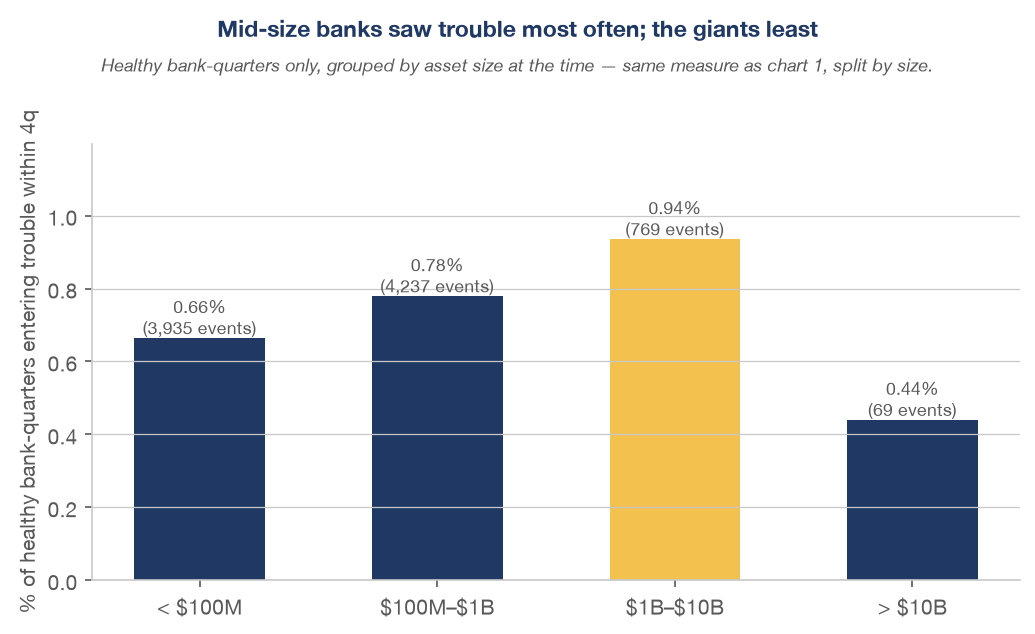

In [13]:
bins = [0, 100_000, 1_000_000, 10_000_000, np.inf]
labels = ["< \\$100M", "\\$100M\u2013\\$1B", "\\$1B\u2013\\$10B", "> \\$10B"]
healthy_sz = healthy.assign(size=pd.cut(healthy["ASSET"], bins=bins, labels=labels))
sz = healthy_sz.groupby("size", observed=True)["onset_4q"].agg(["mean", "sum", "count"])

fig, ax = plt.subplots(figsize=(7, 3.8))
colors = [GOLD if m == sz["mean"].max() else NAVY for m in sz["mean"]]
bars = ax.bar(sz.index.astype(str), sz["mean"] * 100, color=colors, width=0.55)
for b, (m, s) in zip(bars, zip(sz["mean"], sz["sum"])):
    ax.text(b.get_x() + b.get_width()/2, m*100, f"{m:.2%}\n({int(s):,} events)", ha="center", va="bottom", fontsize=8.5, color=MIDGRAY)
plt.suptitle("Mid-size banks saw trouble most often; the giants least", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Healthy bank-quarters only, grouped by asset size at the time \u2014 same measure as chart 1, split by size.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_ylabel("% of healthy bank-quarters entering trouble within 4q")
ax.set_ylim(0, sz["mean"].max()*100*1.28)
plt.tight_layout(); plt.show()

## 9 · Where data is missing

Share of bank-quarters missing each feature, by year. White = complete, navy = fully missing.

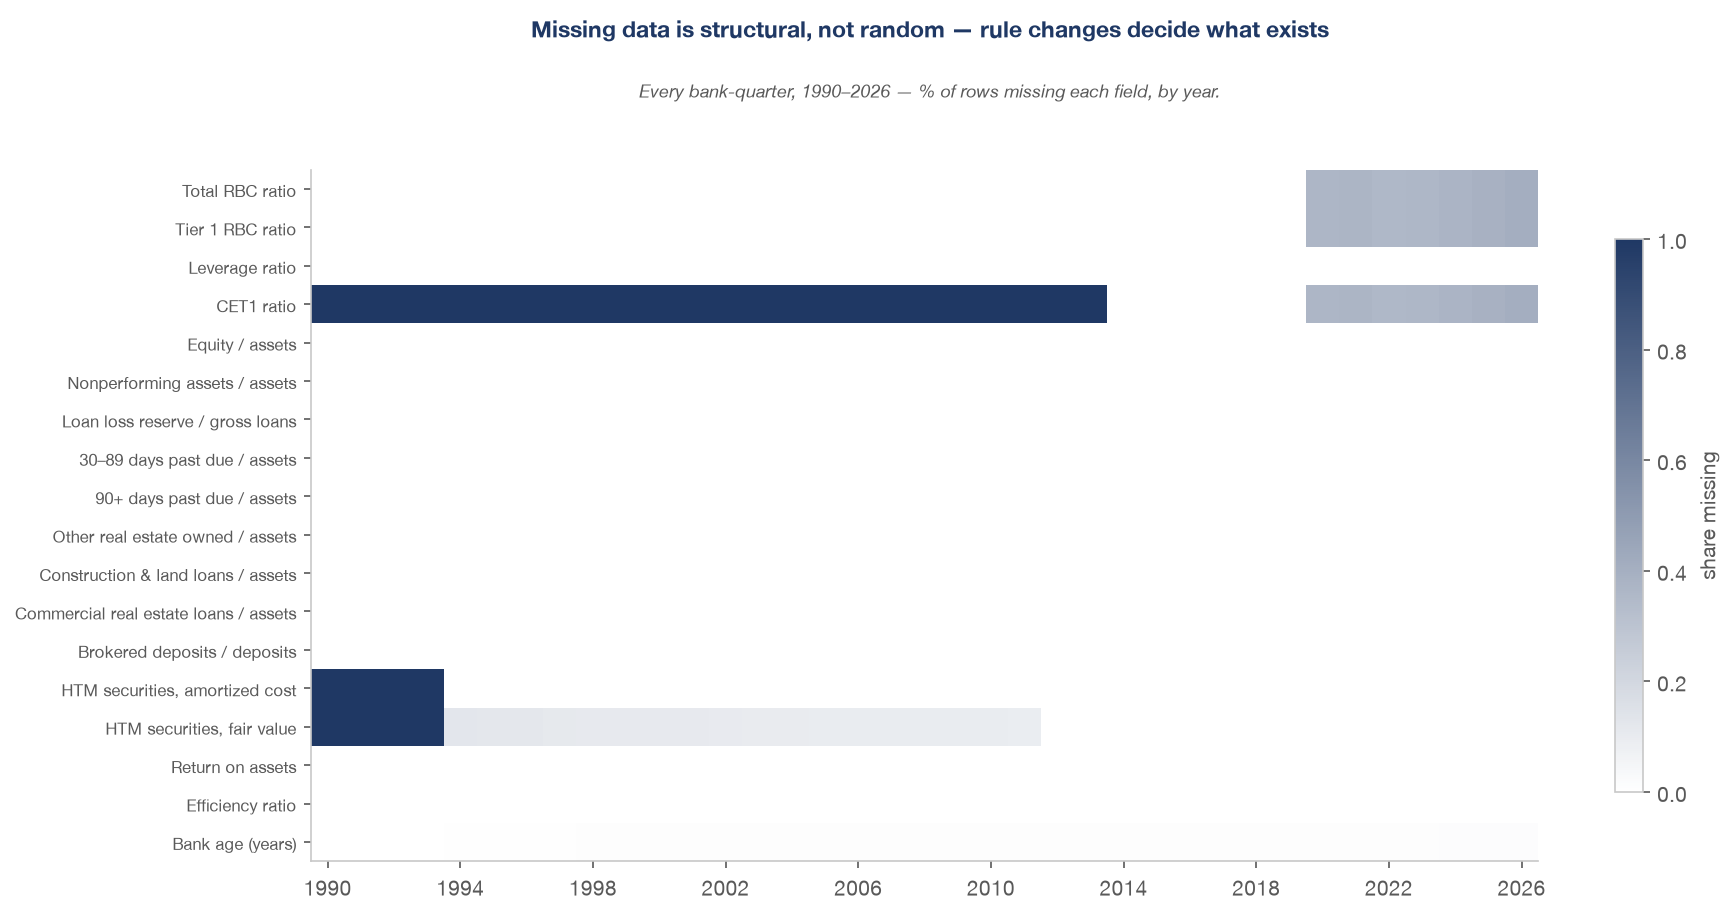

In [14]:
miss_cols = ["RBCRWAJ", "RBC1RWAJ", "RBC1AAJ", "RBCT1CER", "EQV", "NPERFV", "LNATRESR",
             "P3ASSETR", "P9ASSETR", "ORER", "LNRECONSR", "LNRENRESR", "BROR", "SCHA", "SCHF",
             "ROA", "EEFFR", "AGE_YEARS"]
yrs = panel["REPDTE"].dt.year
miss = pd.DataFrame({c: panel[c].isna().groupby(yrs).mean() for c in miss_cols}).T

fig, ax = plt.subplots(figsize=(12.5, 5.5))
im = ax.imshow(miss.values, aspect="auto", cmap=NAVY_SEQ, vmin=0, vmax=1)
ax.set_xticks(range(0, len(miss.columns), 4)); ax.set_xticklabels(miss.columns[::4])
ax.set_yticks(range(len(miss.index)))
ax.set_yticklabels([FEATURE_NAMES.get(c, c) for c in miss.index], fontsize=8)
ax.grid(False)
plt.suptitle("Missing data is structural, not random — rule changes decide what exists", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Every bank-quarter, 1990\u20132026 \u2014 % of rows missing each field, by year.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
fig.colorbar(im, shrink=0.8, label="share missing")
plt.tight_layout(); plt.show()

## 10 · The fake 2020 drop

As reported, the median capital ratio plunges ~3 points in 2020. No bank lost that capital:
the CBLR rule change made the FDIC fill the field with placeholder **zeros** for thousands of
small, well-capitalized banks. Cleaning the placeholders removes most of the drop; the small
remaining step is composition — the banks that left the reporting pool were the small,
high-capital ones.

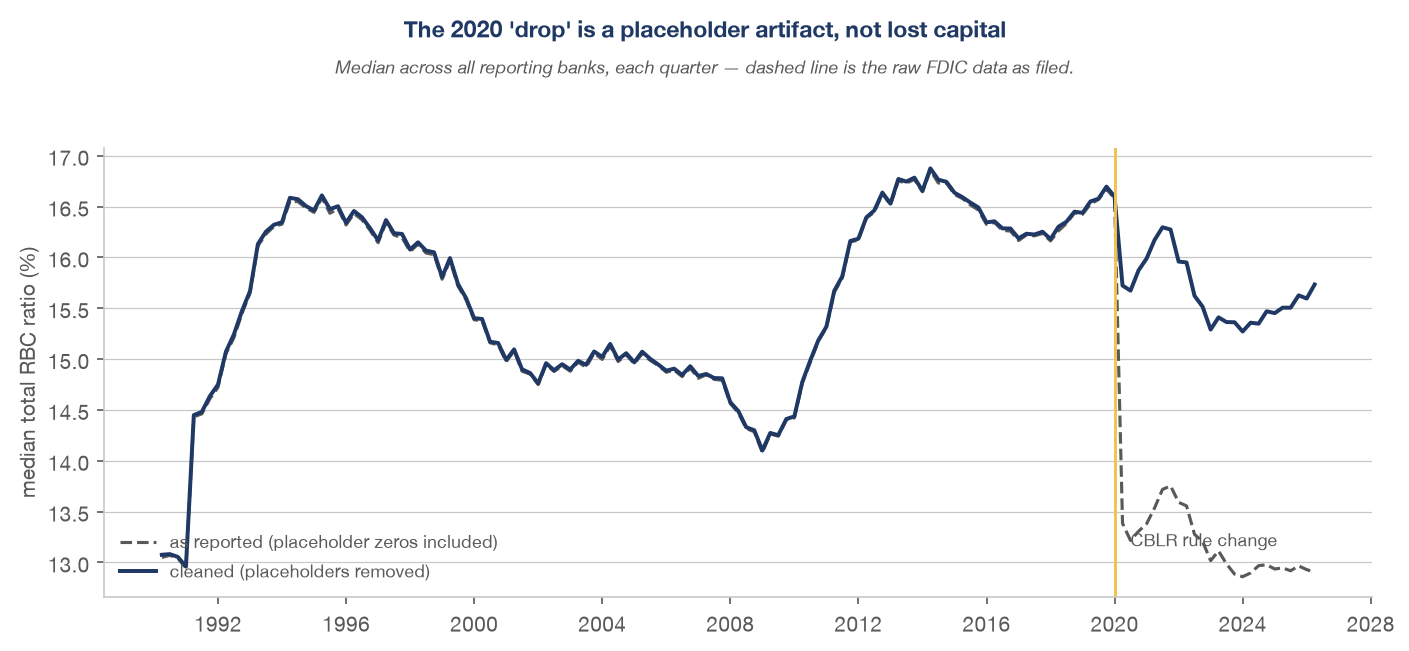

In [15]:
# reconstruct the as-reported series from the raw files (the panel is already cleaned)
raw_fin = pd.concat(
    (pd.read_parquet(f, columns=["REPDTE", "RBCRWAJ"]) for f in sorted((Path("..") / "data" / "raw").glob("financials_*.parquet"))),
    ignore_index=True,
)
raw_fin["REPDTE"] = pd.to_datetime(raw_fin["REPDTE"])
raw_fin = raw_fin[raw_fin["REPDTE"] >= "1990-01-01"]
raw_med = raw_fin.groupby("REPDTE")["RBCRWAJ"].median()
clean_med = panel.groupby("REPDTE")["RBCRWAJ"].median()

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ax.plot(raw_med.index, raw_med.values, color=MIDGRAY, linewidth=1.5, linestyle="--", label="as reported (placeholder zeros included)")
ax.plot(clean_med.index, clean_med.values, color=NAVY, linewidth=1.9, label="cleaned (placeholders removed)")
ax.axvline(pd.Timestamp("2020-01-01"), color=GOLD, linewidth=1.4)
ax.annotate("CBLR rule change", xy=(pd.Timestamp("2020-06-30"), raw_med.min()+0.3), fontsize=8.5, color=MIDGRAY)
plt.suptitle("The 2020 'drop' is a placeholder artifact, not lost capital", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Median across all reporting banks, each quarter — dashed line is the raw FDIC data as filed.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_ylabel("median total RBC ratio (%)")
ax.legend(fontsize=8.5, loc="lower left")
plt.tight_layout(); plt.show()

## 11 · Overlapping features

Correlation between the six loan-type features. Near-zero = each carries its own information.

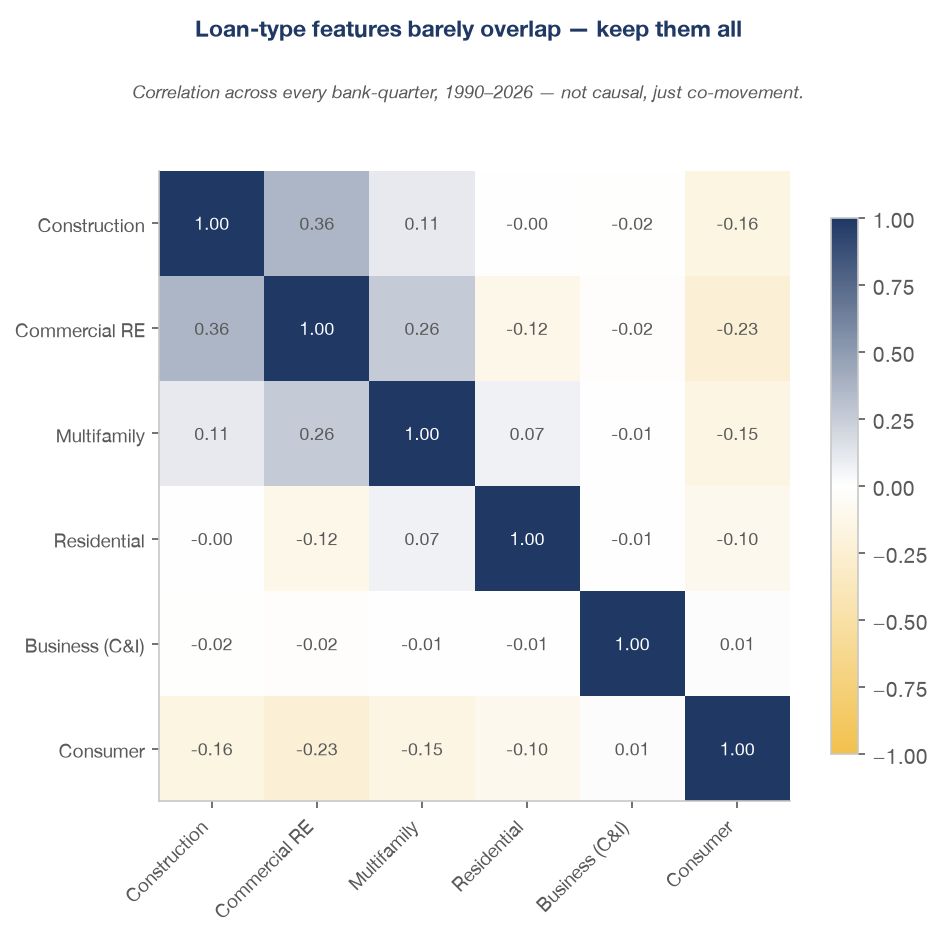

In [16]:
loan_cols = ["LNRECONSR", "LNRENRESR", "LNREMULTR", "LNRERESR", "IDNCCIR", "LNCONR"]
loan_names = ["Construction", "Commercial RE", "Multifamily", "Residential", "Business (C&I)", "Consumer"]
corr = panel[loan_cols].corr()

fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap=NAVY_GOLD)
ax.set_xticks(range(6)); ax.set_xticklabels(loan_names, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(6)); ax.set_yticklabels(loan_names, fontsize=9)
ax.grid(False)
for i in range(6):
    for j in range(6):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) > 0.6 else MIDGRAY)
plt.suptitle("Loan-type features barely overlap — keep them all", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Correlation across every bank-quarter, 1990\u20132026 \u2014 not causal, just co-movement.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
fig.colorbar(im, shrink=0.85)
plt.tight_layout(); plt.show()

## 12 · Rates vs. trouble

The 2008 wave followed a hiking cycle; the 2021\u201323 wave began as rates turned. Suggestive, not causal \u2014 macro earns a slot as a feature.

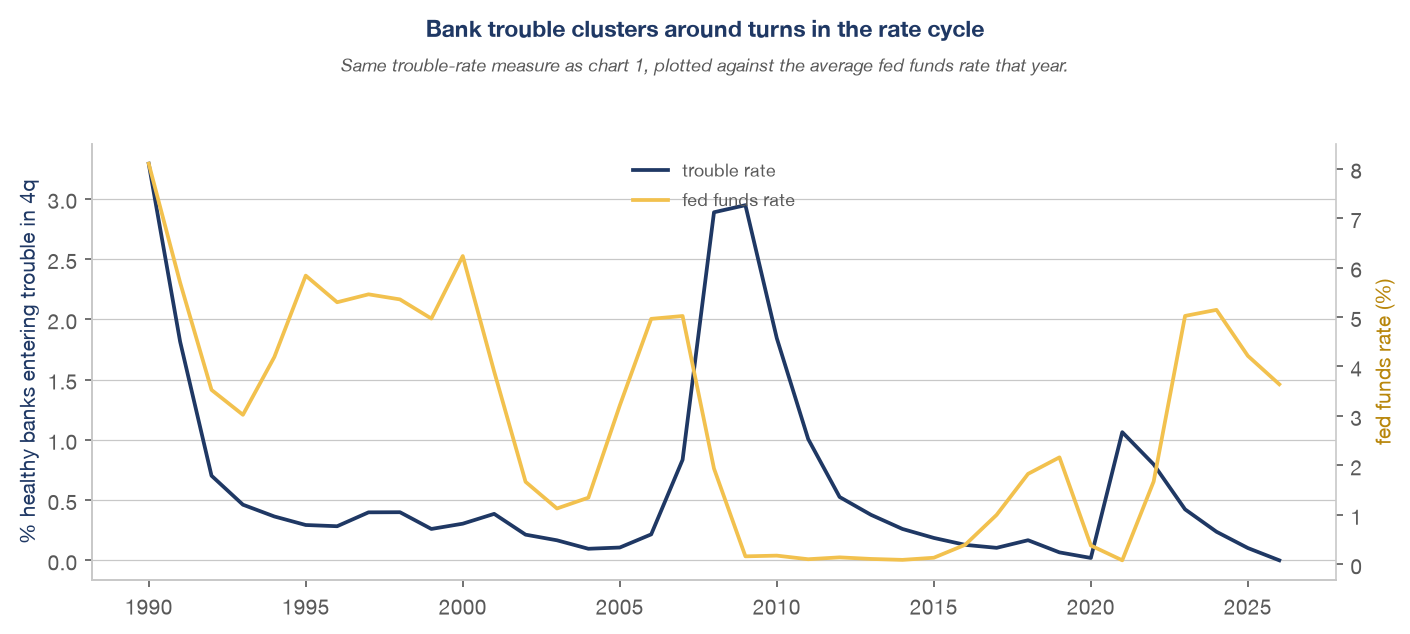

In [17]:
yr_rate = healthy.assign(year=healthy["REPDTE"].dt.year).groupby("year")["onset_4q"].mean() * 100
ff = panel.groupby(panel["REPDTE"].dt.year)["FEDFUNDS"].mean()

fig, ax1 = plt.subplots(figsize=(9.5, 3.8))
ax1.plot(yr_rate.index, yr_rate.values, color=NAVY, linewidth=1.8, label="trouble rate")
ax1.set_ylabel("% healthy banks entering trouble in 4q", color=NAVY)
ax2 = ax1.twinx()
ax2.plot(ff.index, ff.values, color=GOLD, linewidth=1.8, label="fed funds rate")
ax2.set_ylabel("fed funds rate (%)", color="#B8860B")
ax2.spines["right"].set_visible(True); ax2.grid(False)
plt.suptitle("Bank trouble clusters around turns in the rate cycle", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Same trouble-rate measure as chart 1, plotted against the average fed funds rate that year.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], fontsize=8.5, loc="upper center")
plt.tight_layout(); plt.show()

## 13 · Trouble by state

Where the 2008–2011 wave hit hardest (states with at least 2,000 healthy bank-quarters in the window).

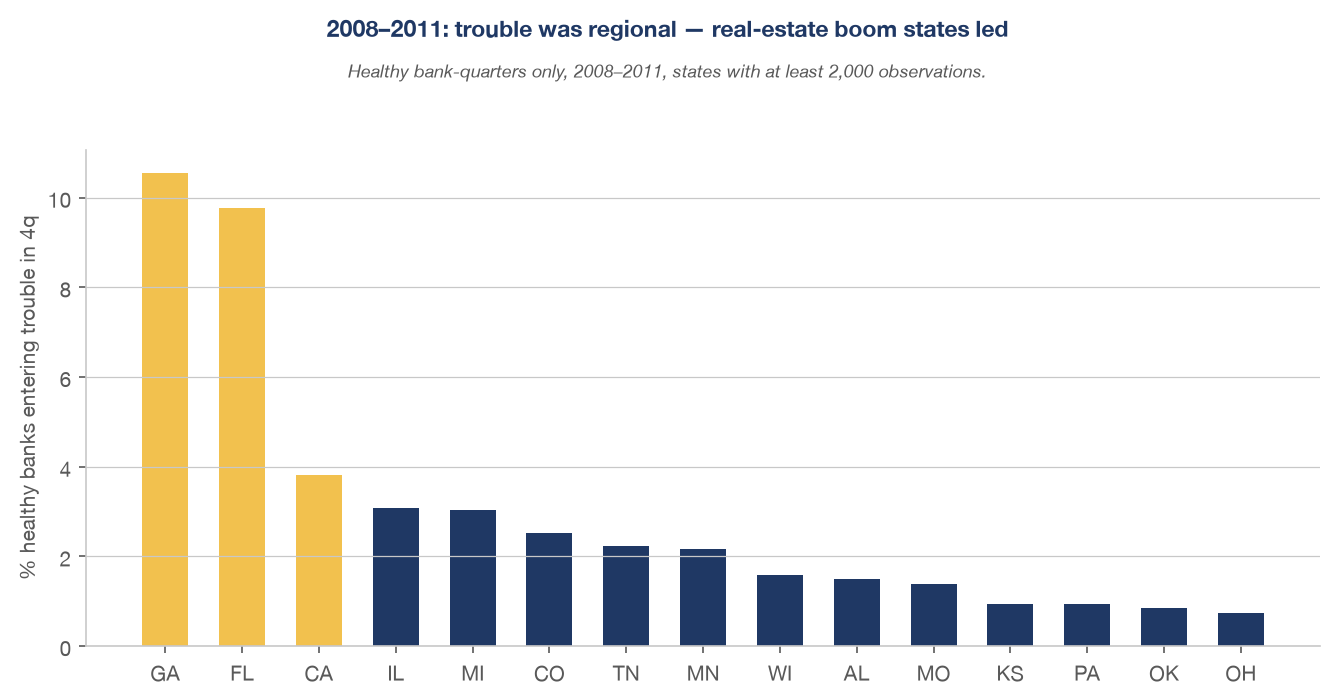

In [18]:
gfc = healthy[(healthy["REPDTE"] >= "2008-01-01") & (healthy["REPDTE"] <= "2011-12-31")]
st = gfc.groupby("STALP")["onset_4q"].agg(["mean", "count"])
st = st[st["count"] >= 2000].sort_values("mean", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(st.index, st["mean"] * 100, color=[GOLD if i < 3 else NAVY for i in range(len(st))], width=0.6)
plt.suptitle("2008–2011: trouble was regional — real-estate boom states led", color=NAVY, fontweight="bold", fontsize=11, y=1.10)
fig.text(0.5, 1.00, "Healthy bank-quarters only, 2008\u20132011, states with at least 2,000 observations.", ha="center", fontsize=8.5, style="italic", color=MIDGRAY)
ax.set_ylabel("% healthy banks entering trouble in 4q")
plt.tight_layout(); plt.show()

In [19]:
panel

,CERT,REPDTE,NAME,ASSET,DEP,RBC1AAJ,RBC1RWAJ,RBCRWAJ,RBCT1CER,RBCT1J,...,AGE_YEARS,pca_tier,is_distressed,is_healthy,quarters_to_onset,onset_4q,near_merge_exit,roa_artifact,fast_failure,_pos
0,8,1990-03-31,FLEET BANK OF MAINE,1856556,1530183.0,7.369650,9.39,10.758763,NaN,133230.0,...,56.358658,well,False,True,NaN,0.0,False,False,False,0
1,8,1990-06-30,FLEET BANK OF MAINE,1881454,1529305.0,6.992111,9.33,10.712806,NaN,130354.0,...,56.607803,well,False,True,NaN,0.0,False,False,False,1
2,8,1990-09-30,FLEET BANK OF MAINE,1914284,1502336.0,7.165424,9.53,10.906755,NaN,130911.0,...,56.859685,well,False,True,NaN,0.0,False,False,False,2
3,8,1990-12-31,FLEET BANK OF MAINE,1809474,1470999.0,6.442283,9.06,10.452007,NaN,121369.0,...,57.111567,well,False,True,NaN,0.0,False,False,False,3
4,8,1991-03-31,FLEET BANK OF MAINE,2738380,2330638.0,6.187796,8.20,9.532702,NaN,155581.0,...,57.357974,adequate,False,True,NaN,0.0,False,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1258883,91393,1996-06-30,PROFESSIONAL BANK,88250,77173.0,11.108098,15.38,16.633992,NaN,9421.0,...,13.325120,well,False,True,NaN,0.0,False,False,False,25
1258884,91393,1996-09-30,PROFESSIONAL BANK,88268,75840.0,11.293637,16.10,17.360053,NaN,9508.0,...,13.577002,well,False,True,NaN,0.0,True,False,False,26
1258885,91393,1996-12-31,PROFESSIONAL BANK,93585,78195.0,10.530762,16.51,17.768309,NaN,9599.0,...,13.828884,well,False,True,NaN,0.0,True,False,False,27
1258886,91393,1997-03-31,PROFESSIONAL BANK,85160,68073.0,11.319501,16.93,18.191136,NaN,9711.0,...,14.075291,well,False,True,NaN,0.0,True,False,False,28


## Recap

1. Trouble is rare (~0.7% of healthy bank-quarters) and arrives in three waves.
2. Most banks never see trouble; repeat episodes are uncommon.
3. When trouble comes, the signal usually exists 1–4 quarters ahead.
4. The classic vitals (capital, bad loans, earnings, funding) clearly separate sick from healthy.
5. Decline builds over ~2 years — early warning is possible.
6. Single-feature AUC ranks capital and asset-quality ratios highest.
7. But SVB shows a failure mode the vitals miss: hidden bond losses.
8. Small banks get in trouble far more often than large ones.
9-10. Missing data is structural (rule changes), including the fake 2020 drop.
11. Loan-mix features barely overlap — all six earn a slot.
12. Rate spikes precede the modern trouble waves — macro belongs in the model.
13. Crisis trouble is regional — geography matters.